In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import classification_report

In [5]:
from collections import defaultdict
from shutil import copy
import os

def setup_training_data(txtfile, source, destination, 
                        food_list=['cheesecake', 'chicken_curry', 'chocolate_cake', 'club_sandwich', 
                                   'cup_cakes', 'donuts', 'french_toast', 'fried_rice', 
                                   'mussels', 'samosa']):
    food_types = defaultdict(list)
    
    with open(txtfile, "r") as file:
        lines = [line.strip() for line in file.readlines()]
        for l in lines:
            food_type = l.split("/")
            if food_type[0] in food_list:
                food_types[food_type[0]].append(food_type[1])
    
    for food in food_types.keys():
        print("Processing:", food)
        food_dest_dir = os.path.join(destination, food)
        if not os.path.exists(food_dest_dir):
            os.makedirs(food_dest_dir)
        for n in food_types[food]:
            for ext in ['.jpg', '.png', '.jpeg']:
                src_path = os.path.join(source, food, n + ext)
                if os.path.exists(src_path):
                    copy(src_path, os.path.join(food_dest_dir, n + ext))
                    break
            else:
                print(f"Warning: Source file {os.path.join(source, food, n)} not found.")


In [8]:
setup_training_data('NewDataset/meta/meta/train.txt', 'NewDataset/images', 'train')
setup_training_data('NewDataset/meta/meta/test.txt', 'NewDataset/images', 'test')

Processing: cheesecake
Processing: chicken_curry
Processing: chocolate_cake
Processing: club_sandwich
Processing: cup_cakes
Processing: donuts
Processing: french_toast
Processing: fried_rice
Processing: mussels
Processing: samosa
Processing: cheesecake
Processing: chicken_curry
Processing: chocolate_cake
Processing: club_sandwich
Processing: cup_cakes
Processing: donuts
Processing: french_toast
Processing: fried_rice
Processing: mussels
Processing: samosa


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_gen = ImageDataGenerator(rotation_range=30, rescale=1./255, validation_split=0.2)

In [14]:
image_size = (235, 235)
train_gen = data_gen.flow_from_directory('train', target_size=image_size) # class_mode default categorical
test_gen = data_gen.flow_from_directory('test', target_size=image_size) # default batch_size is 32

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [16]:
from tensorflow.keras.applications import InceptionV3

input_shape = (235, 235, 3) # 235, 235 stands for w and h. The 3 stands for the three channels for RGB
inception_model = InceptionV3(weights="imagenet", input_shape=input_shape, include_top=False)

inception_model.trainable = False # freeze weights

In [17]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPool2D, GlobalAveragePooling2D

model = Sequential()
model.add(inception_model)  # Assuming inception_model is preloaded
model.add(GlobalAveragePooling2D())
model.add(Dense(64, activation="relu"))  # 64 units
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))  # Change to 10 classes

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,934,570 (83.67 MB)

 Trainable params: 131,786 (514.79 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [18]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

earlystopping = EarlyStopping(min_delta=0.001, patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(filepath='food_model.weights.h5',
                              verbose=1,
                              save_best_only=True,
                              save_weights_only=True)


In [23]:
history = model.fit(train_gen, validation_data=test_gen, epochs=30, verbose=1, callbacks=[checkpoint, earlystopping])

c:\Users\HP\Documents\STUDY\Python\Jupytr Notebook\myenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4923 - loss: 1.5168
Epoch 1: val_loss improved from inf to 0.61007, saving model to food_model.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 343s 1s/step - accuracy: 0.4928 - loss: 1.5154 - val_accuracy: 0.7988 - val_loss: 0.6101
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.7113 - loss: 0.8673
Epoch 2: val_loss improved from 0.61007 to 0.56687, saving model to food_model.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.7113 - loss: 0.8673 - val_accuracy: 0.8168 - val_loss: 0.5669
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.7395 - loss: 0.7689
Epoch 3: val_loss improved from 0.56687 to 0.53184, saving model to food_model.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.7396 - loss: 0.7688 - val_accuracy: 0.8220 - val_loss: 0.5318
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.7533 - loss: 0.7536
Epoch 4: val_loss did not impro

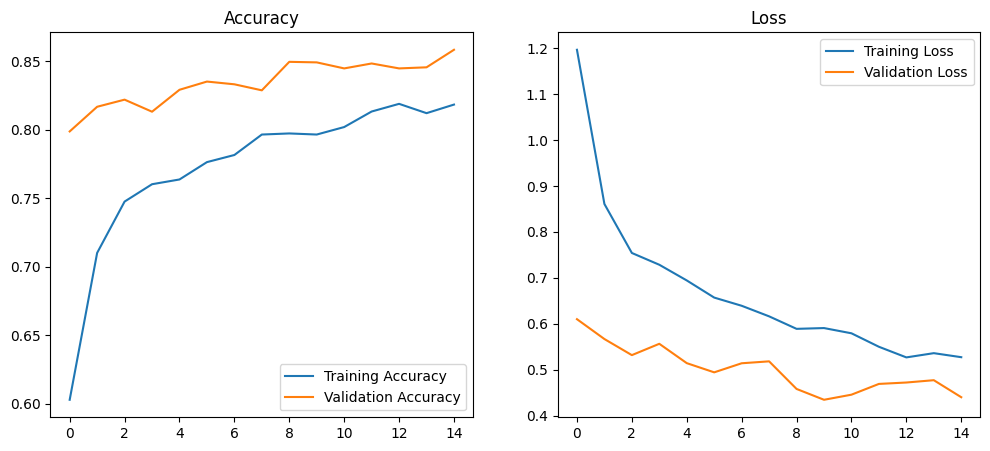

In [24]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    metrics = history.history
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(metrics['accuracy'], label='Training Accuracy')
    plt.plot(metrics['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(metrics['loss'], label='Training Loss')
    plt.plot(metrics['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.legend()

    plt.show()

plot_metrics(history)


In [25]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.2f}, Test Loss: {test_loss:.2f}")


79/79 ━━━━━━━━━━━━━━━━━━━━ 58s 732ms/step - accuracy: 0.8576 - loss: 0.4458
Test Accuracy: 0.85, Test Loss: 0.46


In [31]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

image_path = "test/chicken_curry/53308.jpg"  # Path to the image you want to predict
image_size = (235, 235)  # The size used during training

# Load and preprocess the image
img = load_img(image_path, target_size=image_size)  # Resize image
img_array = img_to_array(img)  # Convert image to array
img_array = img_array / 255.0  # Scale pixel values to [0, 1] (if required)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension


In [ ]:
predictions = model.predict(img_array)  # Returns probabilities for each class
# Class names (ensure they match the order used during training)
class_names = ['cheesecake', 'chicken_curry', 'chocolate_cake', 'club_sandwich',
               'cup_cakes', 'donuts', 'french_toast', 'fried_rice', 'mussels', 'samosa']

# Get the predicted class
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_index]
print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: chicken_curry


In [33]:
model.save("food_classification_model.keras")  # Save model in .keras format


model.save('calorme_food_classifier.h5')


from tensorflow.keras.models import load_model

loaded_model = load_model('calorme_food_classifier.h5')


In [34]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("food_classification_model.keras")  # or "food_classification_model.h5"


In [35]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

image_path = "test/fried_rice/983389.jpg"  # Replace with your image path
image_size = (235, 235)  # Resize to the size used during training

# Preprocess the image
img = load_img(image_path, target_size=image_size)
img_array = img_to_array(img)
img_array = img_array / 255.0  # Scale pixel values (if applicable)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension


In [6]:
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]

# Define the class names in the same order as used during training
class_names = ['cheesecake', 'chicken_curry', 'chocolate_cake', 'club_sandwich', 
               'cup_cakes', 'donuts', 'french_toast', 'fried_rice', 'mussels', 'samosa']
predicted_class = class_names[predicted_class_index]

print(f"Predicted class: {predicted_class}")


NameError: name 'model' is not defined

In [44]:
# Save the model in the SavedModel format
model.export("saved_model/my_food_model")



INFO:tensorflow:Assets written to: saved_model/my_food_model\assets


INFO:tensorflow:Assets written to: saved_model/my_food_model\assets


Saved artifact at 'saved_model/my_food_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 235, 235, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2785550495824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550497552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550493328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550496016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550498704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550497360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550499472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550499088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550493136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550498512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2785550498128: TensorSp

In [45]:
# Initialize the TFLite Converter
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model/my_food_model")

# Optional: Optimize the model (e.g., for smaller size or speed)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model to TFLite format
tflite_model = converter.convert()

# Save the TFLite model to a file
with open("my_model.tflite", "wb") as f:
    f.write(tflite_model)


BELOW IS THE CODE TO IMPORT THE TRAINED MODEL IN APP USING TENSORLIIE AND PREDICT

In [19]:
import numpy as np
import tensorflow as tf
from PIL import Image

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="C:/Users/HP/Documents/STUDY/Python/Jupytr Notebook/my_model.tflite")#C:\Users\HP\Documents\STUDY\Python\Jupytr Notebook\my_model.tflite
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Function to preprocess the image
def preprocess_image(image_path, input_size):
    # Load the image
    image = Image.open(image_path).convert("RGB")  # Convert to RGB if needed
    # Resize the image to match model input
    image = image.resize((input_size[1], input_size[2]))
    # Convert to numpy array
    image_array = np.array(image, dtype=np.float32)
    # Normalize pixel values (if your model expects normalized input)
    image_array /= 255.0
    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)
    return image_array

# Get input size from the model's input details
input_shape = input_details[0]['shape']  # E.g., [1, 224, 224, 3]

# Preprocess your image
image_path = "C:/Users/HP/Downloads/41jAYwE6A8L._AC_UF1000,1000_QL80_.jpg"  # Replace with the path to your image
input_data = preprocess_image(image_path, input_shape)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
print("Prediction:", output_data)


Prediction: [[1.0593667e-03 6.2954205e-05 1.1669378e-02 3.7378454e-04 7.5385712e-02
  9.0847421e-01 2.0850782e-04 2.7951992e-05 6.1400887e-04 2.1241810e-03]]


In [20]:
class_names = ['cheesecake', 'chicken_curry', 'chocolate_cake', 'club_sandwich', 
               'cup_cakes', 'donuts', 'french_toast', 'fried_rice', 'mussels', 'samosa']
predicted_class_index = np.argmax(output_data, axis=1)[0]
predicted_class = class_names[predicted_class_index]
print(f"Predicted class: {predicted_class}")

Predicted class: donuts
